In [1]:
from ioMicro import *
import pickle
psf = pickle.load(open(r'C:\Scripts\NMERFISH\psfs\dic_psfff_scope6_60X_cy5_300pix.pkl','rb'))

Loaded decoded: -1.6101274490356445
Fraction of GFP decoded above confidence: 0.34131044726852616


Text(0.5, 1.0, '0.12')

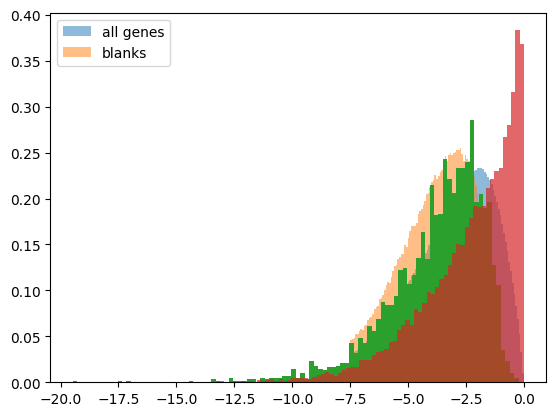

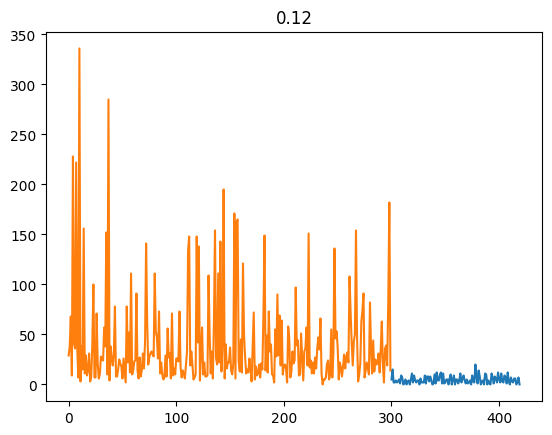

In [156]:
save_folder=r'\\192.168.0.15\cherry2\Zane\300CRE_Schizo_withT7_AdamRNA_WTC11__10_19_2024_HMERFISH_Analysis'#
#r'\\192.168.0.15\cherry2\Zane\300CRE_Schizo_withT7_AdamRNA_WTC11__10_19_2024_HMERFISH_AnalysisGFP'
ifov = 25
fov = 'Conv_zscan1_'+str(ifov).zfill(3)
#save_folder =r'\\merfish19\merfish19\20240422_R136BICAN2kgene\MERFISHPlate3_4\AnalysisBB_P34_bkremove'
#save_folder =r'R:\Roy\2000gnMERFISH_DCBB_5_9_2024\MERFISH_AnalysisP5P6'
save_fl_ref = r'\\192.168.0.15\cherry2\Zane\300CRE_Schizo_withT7_AdamRNA_WTC11__10_19_2024_HMERFISH_Analysis\scores_ref.pkl'
dec = decoder_simple(save_folder,fov,set_='')
dec.ncols = 3
dec.load_decoded()
dec.dist_best=np.load(dec.decoded_fl)['dist_best']
if False:
    scoresRef = get_score_per_color(dec,include_dbits=True)
    pickle.dump(scoresRef,open(r'\\192.168.0.15\cherry2\Zane\300CRE_Schizo_withT7_AdamRNA_WTC11__10_19_2024_HMERFISH_Analysis\scoresRef.pkl','wb'))
else:
    scoresRef = pickle.load(open(r'\\192.168.0.15\cherry2\Zane\300CRE_Schizo_withT7_AdamRNA_WTC11__10_19_2024_HMERFISH_Analysis\scoresRef.pkl','rb'))
get_score_withRef(dec,scoresRef,plt_val=True,gene=None,iSs = None,th_min=-7.5,include_dbits=True)

gfp_signal_col0 = save_folder+os.sep+dec.fov+r'--H17_MER_GFP--col0__Xhfits.npz'
gfp_signal_col1 = save_folder+os.sep+dec.fov+r'--H17_MER_GFP--col1__Xhfits.npz'
Xh0 = np.load(gfp_signal_col0)['Xh']
Xh1 = np.load(gfp_signal_col1)['Xh']

Xh0_ = Xh0[(Xh0[:,-2]>0.6)&(Xh0[:,-1]>np.exp(9.5))]### Threshild based on quality of spot
Xh1_ = Xh1[(Xh1[:,-2]>0.6)&(Xh1[:,-1]>np.exp(9.5))]
X0 = Xh0_[:,:3]
X1 = Xh1_[:,:3]
from scipy.spatial import KDTree
dists,inds = KDTree(X0).query(X1)
X1F = Xh1_[(dists<2)][:,[0,1,2,-1]]
if False:
    plt.hist(np.log(Xh0_[:,-1]),density=True,bins=30)
    plt.hist(np.log(Xh0_[inds[(dists<2)],-1]),density=True,bins=30,alpha=0.5)
    plt.hist(np.log(Xh1_[:,-1]),density=True,bins=30)
    plt.hist(np.log(Xh1_[dists<1.5,-1]),density=True,bins=30,alpha=0.5)
if False:
    imGFP = read_im(r'\\192.168.0.15\cherry2\Zane\300CRE_Schizo_withT7_AdamRNA_WTC11__10_19_2024\H17_MER_GFP'+os.sep+dec.fov)
    import napari
    V = napari.view_image(imGFP)
    V.add_points(X1F[:,:3],face_color=[0,0,0,0],edge_color='r')
### apply drift
drifts,flds,fov_,fl_ref = np.load(dec.drift_fl,allow_pickle=True)
from worker_ZaneWTC_H import *
fl = r'\\192.168.0.15\cherry2\Zane\300CRE_Schizo_withT7_AdamRNA_WTC11__10_19_2024\H17_MER_GFP'+os.sep+dec.fov
drift = get_best_translation_pointsV2(fl,fl_ref,save_folder,'',resc=5)
X1FD = X1F.copy()
X1FD[:,:3]=X1F[:,:3]+drift[0]

X_MERFISH = np.nanmean(dec.XH_pruned[:,:,:3],axis=1)
tree = KDTree(X_MERFISH)
dist,indMER = tree.query(X1FD[:,:3],workers=10)

keepMER = indMER[dist<2]

XH_pruned = dec.XH_pruned[keepMER]
scoreA = dec.scoreA[keepMER]
icodesN = dec.icodesN[keepMER]
ibad = [ign for ign,gn in enumerate(dec.gns_names) if 'blank' in gn]
isbad = np.in1d(icodesN,ibad)
isgood=~isbad

plt.hist(scoreA[isbad],density=True,bins=100)
plt.hist(scoreA[isgood],density=True,bins=100,alpha=0.7);

th=-2
np.sum(dec.scoreA>th),np.sum(scoreA>th)
X1FD.shape,scoreA.shape
print("Fraction of GFP decoded above confidence:",np.sum(scoreA>th)/len(X1FD))#,len(scoreA)/len(X1FD)

XH_prunedf = XH_pruned[scoreA>th]
scoreAf = scoreA[scoreA>th]
icodesNf = icodesN[scoreA>th]
dist_bestf = dec.dist_best[keepMER][scoreA>th]
bigSpot = X1FD[dist<2][scoreA>th][:,-1]>np.exp(12)
#XH_prunedf = XH_pruned[scoreA>th]

_,cts = np.unique(list(icodesNf)+list(np.arange(len(dec.gns_names))),return_counts=True)
cts = cts-1
plt.figure()
plt.plot(ibad,cts[ibad])
igood = np.setdiff1d(np.arange(len(cts)),ibad)
plt.plot(igood,cts[igood])
plt.title(np.round(np.mean(cts[ibad])/np.mean(cts[igood]),2))

In [157]:
cts25=cts

In [155]:
cts20=cts

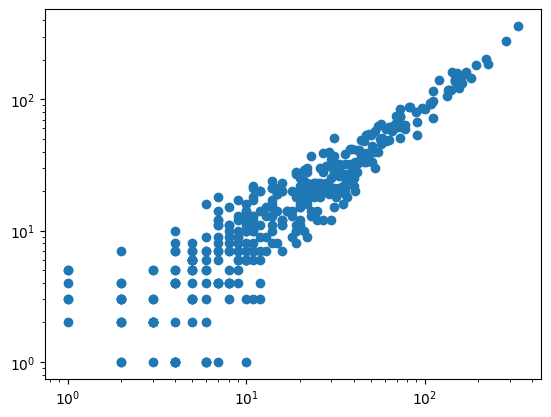

In [159]:
plt.loglog(cts25,cts20,'o')

In [137]:
imGFP = read_im(r'\\192.168.0.15\cherry2\Zane\300CRE_Schizo_withT7_AdamRNA_WTC11__10_19_2024\H17_MER_GFP'+os.sep+dec.fov)
import napari
V = napari.view_image(imGFP)
V.add_points(X1F[:,:3],face_color=[0,0,0,0],edge_color='g')
V.add_points(X1F[X1F[:,-1]>np.exp(12),:3],face_color=[0,0,0,0],edge_color='r')

<Points layer 'Points [1]' at 0x25b3635fa00>

In [161]:
imPolyT = read_im(r'\\192.168.0.15\cherry2\Zane\300CRE_Schizo_withT7_AdamRNA_WTC11__10_19_2024\HpolyT\Conv_zscan1_064.zarr')
import napari
V = napari.view_image(imPolyT)

In [162]:
T7spots = np.load(r'\\192.168.0.15\cherry2\Zane\300CRE_Schizo_withT7_AdamRNA_WTC11__10_19_2024_TMERFISH_Analysis\decodedNew_Conv_zscan1_064--.npz', allow_pickle=True)
CREspots = np.load(r'\\192.168.0.15\cherry2\Zane\300CRE_Schizo_withT7_AdamRNA_WTC11__10_19_2024_HMERFISH_Analysis\decodedNew_Conv_zscan1_064--.npz', allow_pickle=True)


In [190]:
mol_names = list(T7spots['icodesN'])
elem = '299'

if elem in mol_names:
    counter = 0
    elem_pos = []
    for i in mol_names:
        if i == elem:
            elem_pos.append(counter)
        counter = counter + 1
    num_spots = len(elem_pos)
    print(str(num_spots) + ' spots found')

spots = [T7spots['XH_pruned'][i] for i in elem_pos]

In [193]:
spots.size

AttributeError: 'list' object has no attribute 'size'

In [194]:
T7spots.keys()

KeysView(NpzFile '\\\\192.168.0.15\\cherry2\\Zane\\300CRE_Schizo_withT7_AdamRNA_WTC11__10_19_2024_TMERFISH_Analysis\\decodedNew_Conv_zscan1_064--.npz' with keys: XH_pruned, icodesN, gns_names, dist_best)

In [204]:
codebook = pd.read_csv(r'C:\Scripts\NMERFISH_Scope6\codebooks\codebookCRE300_schizo.csv')#.values
code = codebook.values[:, 2:]
code.shape


(420, 48)

In [207]:
code_genenames = list(codebook['name'])
len(code_genenames)

420

In [213]:
test_onbits = np.where(code[0] == 1)[0] # the on bit for CRE001
test_onbits

array([0, 3, 6, 9], dtype=int64)

In [212]:
XH_T7_onbits = XH_T7[:, :, -1]

In [221]:
test_onbits_index = np.where(np.all(XH_T7_onbits == test_onbits, axis = 1))[0]

In [222]:
XH_T7[test_onbits_index].shape

(296385, 4, 10)

In [240]:
bright_index = np.where(np.all(XH_T7[test_onbits_index][:, :, -3] > 100000, axis = 1))[0]

In [249]:
np.nanmean(XH_T7[test_onbits_index][bright_index], axis = 1).shape

(7821, 10)

(array([1.125115e+06, 2.877900e+04, 6.637000e+03, 3.269000e+03,
        3.046000e+03, 3.097000e+03, 3.014000e+03, 2.763000e+03,
        2.427000e+03, 1.978000e+03, 1.383000e+03, 8.620000e+02,
        7.420000e+02, 6.770000e+02, 6.100000e+02, 3.850000e+02,
        2.830000e+02, 1.620000e+02, 9.900000e+01, 6.800000e+01,
        5.600000e+01, 3.000000e+01, 2.100000e+01, 1.500000e+01,
        1.000000e+01, 5.000000e+00, 6.000000e+00, 0.000000e+00,
        0.000000e+00, 1.000000e+00]),
 array([   3600.00927734,   72973.1589681 ,  142346.30865885,
         211719.45834961,  281092.60804036,  350465.75773112,
         419838.90742187,  489212.05711263,  558585.20680339,
         627958.35649414,  697331.5061849 ,  766704.65587565,
         836077.80556641,  905450.95525716,  974824.10494792,
        1044197.25463867, 1113570.40432943, 1182943.55402018,
        1252316.70371094, 1321689.85340169, 1391063.00309245,
        1460436.1527832 , 1529809.30247396, 1599182.45216471,
        1668555.60

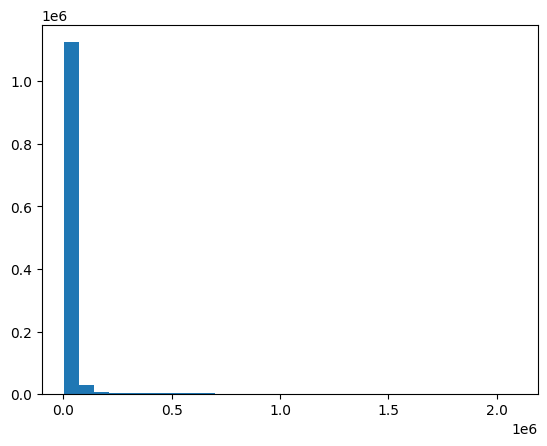

In [231]:
plt.hist(XH_T7[test_onbits_index][:, :, -3].flatten(), bins = 30)

In [ ]:
XH_T7

In [174]:
T7_f = np.nanmean(T7spots['XH_pruned'][:,:,:3],axis=1)

In [197]:
XH_T7 = T7spots['XH_pruned']

In [200]:
XH_T7[0, 1, ]

array([ 2.37610452e-02,  3.15178132e+00,  4.88546875e+02, -1.50167285e+03,
        1.25795648e-01,  5.71695947e+03,  6.75889552e-01,  2.09169160e+04,
        0.00000000e+00,  0.00000000e+00])

In [211]:
XH_T7[:, :, -1].shape

(7985814, 4)

In [195]:
.shape

(7985814, 4, 10)

In [196]:
T7spots['XH_pruned'][0,0,]

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan])

In [176]:
V.add_points(T7spots['XH_pruned'][:,:,:3], face_color='green', size=10)

ValueError: operands could not be broadcast together with shapes (7985814,2,3) (2,) 

In [144]:
#plt.hist(np.log(X1FD[:,-1]))


In [148]:
icodesNf[~bigSpot]

array([120, 297, 249, ..., 232, 159, 111], dtype=int64)

array([ 12,  14,  56,  12, 225,  30,  37, 109,  17,  17, 219,   6,  31,
        13, 145,  16,  17,   5,   7,  12,   3,   9,  22,  91,  11,   1,
        81,  17,  11,   6,  24,   5,  34,  42,  13, 166,  18, 159,   4,
        37,  15,  12,  30,  40,   6,  11,  13,  20,  20,  27,   7,  27,
        11,   4,  61,   7,  62,  16,  70,   6,   8,  29,  25,  72,   9,
         9,  25,   8,  21,  32,  14,  40, 121,  31,  33,  25,  20,  26,
        15,   8, 106,  43,  29,  21,  40,   9,  29,  11,   8,  11,  26,
         8,  52,  29,  17,   7,  66,   4,  14,   9,  11,  26,  11,  61,
        16,   7,   8,  11,   4,  18,  39, 103,  80,  17,  29,  11,   9,
         7,   5, 167,  46,  73,   2,  15,  43,   7,  17,   1,   1,   7,
        97,  50,  12,  13,   7,  57,  89,  33,  21,  66,  29, 153,   6,
        51, 128,   8,  28,  14,  21,  27,  31,  20,   8,  26,  98,   5,
       120, 105,  29,  17,  32,   6, 100,  41,  20,  13,  14,  14,  26,
         9,   1,  28,  47,   5,   6,  18,  11,   9,   8,  19,  1

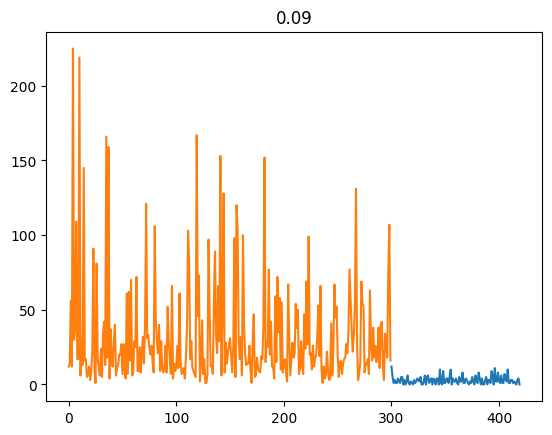

In [152]:
get_counts(icodesNf[~bigSpot])

In [150]:
def get_counts(icodesNf):
    _,cts = np.unique(list(icodesNf)+list(np.arange(len(dec.gns_names))),return_counts=True)
    cts = cts-1
    plt.figure()
    plt.plot(ibad,cts[ibad])
    igood = np.setdiff1d(np.arange(len(cts)),ibad)
    plt.plot(igood,cts[igood])
    plt.title(np.round(np.mean(cts[ibad])/np.mean(cts[igood]),2))
    return cts

In [99]:
#plt.hist(dist,bins=np.linspace(0,10,100))

0.05767524401064773